In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n-pose.pt')
print("Loaded OK")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loaded OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, textwrap

# Base path to your dataset
DATASET_DIR = "/content/drive/MyDrive/datav6"

print("Files in dataset dir:")
print(os.listdir(DATASET_DIR))

Files in dataset dir:
['README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'train', 'test', 'valid']


In [ ]:
print("Preview of data.yaml (if it exists):")
yaml_path = os.path.join(DATASET_DIR, "data.yaml")
if os.path.exists(yaml_path):
    !sed -n '1,80p' "/content/drive/MyDrive/datav6/data.yaml"
else:
    print("data.yaml not found")

Preview of data.yaml (if it exists):
train: ../train/images
val: ../valid/images
test: ../test/images

kpt_shape: [13, 3]
flip_idx: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

nc: 6
names: ['attentive_upright', 'fidgeting_restless', 'hand_raised', 'off_task_phone', 'off_task_sleepy', 'writing_reading_on_task']

roboflow:
  workspace: test-pfn4k
  project: classroomback
  version: 6
  license: CC BY 4.0
  url: https://universe.roboflow.com/test-pfn4k/classroomback/dataset/6

In [ ]:
model.train(
    data="/content/drive/MyDrive/datav6/data.yaml",
    epochs=100,
    imgsz=416,
    batch=16,
    mixup=0.1, # ← Add this: random mixing of images (0.1 = 10%)
    translate=0.2,  # ← Larger translations
    degrees=15,     # ← Rotation
    flipud=0.5,     # ← Vertical flips (important for pose!)
    patience=10, # Stop if no improvement for 10 epochs
    dropout=0.7,        # Add dropout
    weight_decay=0.0001, # L2 regularization
    name="attention-det-v1",
    verbose=True
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/datav6/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.7, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=runs/pose/attention-det-v1/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=attention-det-v12, nbs=64, nms=False, opset=None, optimize=Fals

ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a4d70ec3b30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033

In [ ]:
model.val()

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-pose summary (fused): 82 layers, 3,210,047 parameters, 0 gradients, 8.8 GFLOPs
val: Fast image access ✅ (ping: 6.7±13.7 ms, read: 15.4±10.5 MB/s, size: 47.7 KB)
val: Scanning /content/drive/MyDrive/datav6/valid/labels.cache... 110 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 110/110 24.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.6s/it 11.0s
                   all        110        736      0.923      0.847      0.914      0.711      0.856      0.792      0.812       0.51
     attentive_upright        109        455      0.956      0.953      0.987      0.807       0.94      0.937      0.955      0.803
    fidgeting_restless         32         43      0.892      0.535      0.742      0.534      0.699      0.419      0.494      0.219
           hand_raised          4 

ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a4c5c407ec0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033

In [ ]:
# Define image path
image_path = '/content/drive/MyDrive/datav6/test/images/writing-_mp4-0071_jpg.rf.e7c035f2acaf1a2d738b571703afd688.jpg'
Image=image_path
print(f"Image path: {image_path}")

# Verify file exists
if os.path.exists(image_path):
    size = os.path.getsize(image_path) / 1024
    print(f"✅ File found ({size:.2f} KB)")
else:
    print(f"❌ File not found!")
    print(f"\nTroubleshooting:")
    print(f"1. Check Google Drive mount above")
    print(f"2. Verify path: /content/drive/MyDrive/datav6/test/images/")
    print(f"3. Check filename spelling")

Image path: /content/drive/MyDrive/datav6/test/images/writing-_mp4-0071_jpg.rf.e7c035f2acaf1a2d738b571703afd688.jpg
✅ File found (53.10 KB)


In [ ]:
print("Running pose detection...\n")

results = model.predict(
    image_path,
    save=True,
    conf=0.5
)

print("\n✅ Inference complete!")

Running pose detection...


image 1/1 /content/drive/MyDrive/datav6/test/images/writing-_mp4-0071_jpg.rf.e7c035f2acaf1a2d738b571703afd688.jpg: 640x640 3 attentive_uprights, 1 fidgeting_restless, 2 writing_reading_on_tasks, 8.9ms
Speed: 1.8ms preprocess, 8.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/pose/predict3

✅ Inference complete!


In [ ]:
# Get the directory where results were saved
save_dir = results[0].save_dir
print(f"Results saved in: {save_dir}")

# List files
files = sorted(os.listdir(save_dir))
print(f"\n📋 Files found: {len(files)}")
for i, f in enumerate(files[:10], 1):
    print(f"   {i}. {f}")

if len(files) > 10:
    print(f"   ... and {len(files) - 10} more")

Results saved in: /content/runs/pose/predict3

📋 Files found: 1
   1. writing-_mp4-0071_jpg.rf.e7c035f2acaf1a2d738b571703afd688.jpg


Displaying detected images:

📷 Image 1: writing-_mp4-0071_jpg.rf.e7c035f2acaf1a2d738b571703afd688.jpg



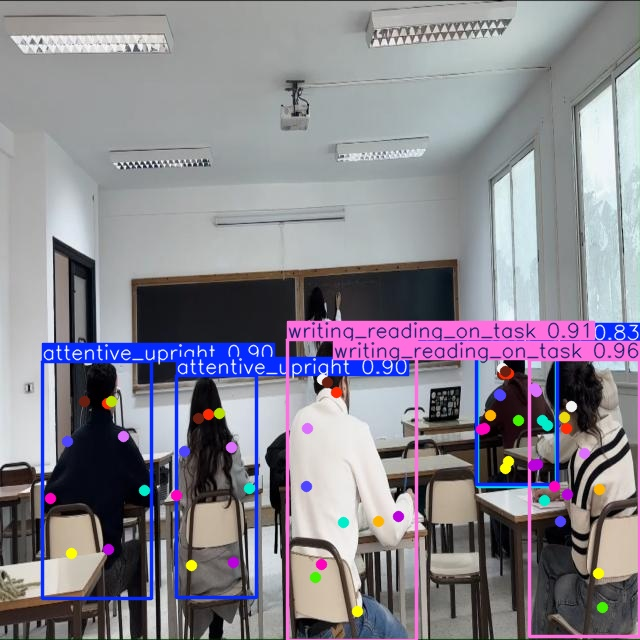


✅ Displayed 1 image(s)


In [ ]:
from IPython.display import Image, display
# Display detected images
print("Displaying detected images:\n")

displayed = 0
for f in files[:5]:
    if f.lower().endswith((".jpg", ".jpeg", ".png")):
        filepath = os.path.join(save_dir, f)
        displayed += 1
        print(f"📷 Image {displayed}: {f}\n")
        display(Image(filename=filepath, width=640))
        print()

if displayed == 0:
    print("❌ No images found to display")
else:
    print(f"✅ Displayed {displayed} image(s)")

In [ ]:
print("\n" + "="*60)
print("📊 DETECTION STATISTICS")
print("="*60)

for result_idx, result in enumerate(results, 1):
    print(f"\nImage {result_idx}:")

    # Count detections
    if result.boxes is not None:
        num_people = len(result.boxes)
        print(f"  People detected: {num_people}")

        if hasattr(result.boxes, 'conf'):
            confs = result.boxes.conf
            print(f"  Confidence: min={confs.min():.3f}, max={confs.max():.3f}, avg={confs.mean():.3f}")
    else:
        print(f"  No people detected")

    # Keypoints
    if hasattr(result, 'keypoints') and result.keypoints is not None:
        print(f"  Keypoints: Detected")

print("\n" + "="*60)
print("✅ Analysis complete!")
print("="*60)


📊 DETECTION STATISTICS

Image 1:
  People detected: 6
  Confidence: min=0.603, max=0.957, avg=0.850
  Keypoints: Detected

✅ Analysis complete!


In [ ]:
from google.colab import files

print("\n📹 Select your MP4 video file...\n")
uploaded = files.upload()

# Get the uploaded video
video_file = list(uploaded.keys())[0]
video_path = f"/content/{video_file}"

print(f"\n✅ Video uploaded: {video_file}")
print(f"📁 Path: {video_path}")


📹 Select your MP4 video file...



Saving totest.mp4 to totest.mp4

✅ Video uploaded: totest.mp4
📁 Path: /content/totest.mp4


In [ ]:
import cv2
# Get video properties using OpenCV
cap = cv2.VideoCapture(video_path)

if cap.isOpened():
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps

    print("\n" + "="*50)
    print("📹 VIDEO INFORMATION")
    print("="*50)
    print(f"Resolution: {width}x{height}")
    print(f"FPS: {fps}")
    print(f"Total Frames: {frame_count}")
    print(f"Duration: {duration:.2f} seconds")
    print("="*50 + "\n")

    cap.release()
else:
    print("❌ Could not open video file")


📹 VIDEO INFORMATION
Resolution: 918x518
FPS: 30.0
Total Frames: 1004
Duration: 33.47 seconds



In [ ]:
model_path = 'runs/pose/attention-det-v1/weights/best.pt'
model = YOLO(model_path)  # Load directly

In [ ]:
if video_path and model is not None:
    print("\n🔄 Running inference with YOUR custom model...")
    print(f"Processing {frame_count} frames\n")

    output_dir = "/content/custom_model_results"
    os.makedirs(output_dir, exist_ok=True)

    # KEY DIFFERENCE: Using our custom model, not pretrained!
    results = model.predict(
        source=video_path,
        save=True,
        project=output_dir,
        name="annotated",
        imgsz=640,
        conf=0.5,
        device=0
    )

    print("\n✅ Inference complete!")
else:
    print("❌ Missing video or model")


🔄 Running inference with YOUR custom model...
Processing 1004 frames


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1004) /content/totest.mp4: 384x640 3 attentive_uprights, 3 off_task_sleepys, 18.1ms
video 1/1 (frame 2/1004) /content/totest.mp4: 384x640 2 attentive_uprights, 3 off_task_sleepys, 15.1ms
video 1/1 (frame 3/1004) /content/totest.mp4: 384x640 2 attentive_uprights, 3 off_task_sleepys, 15.2ms
video 1/1 (frame 4/1004) /content/totest.mp4: 384x640 2 attentive_uprights, 3 

In [ ]:
# Locate the annotated video
result_dir = os.path.join(output_dir, "annotated")
print(f"Looking in: {result_dir}\n")

if os.path.exists(result_dir):
    files_list = os.listdir(result_dir)

    # Find MP4 files
    video_files = [f for f in files_list if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
    if video_files:
        output_video = os.path.join(result_dir, video_files[0])
        file_size = os.path.getsize(output_video) / (1024*1024)

        print("="*50)
        print("✅ OUTPUT VIDEO FOUND")
        print("="*50)
        print(f"Filename: {video_files[0]}")
        print(f"Size: {file_size:.2f} MB")
        print(f"Path: {output_video}")
        print("="*50 + "\n")
    else:
        print(f"❌ No MP4 files found. Files in directory: {files_list}")
        output_video = None
else:
    print(f"❌ Directory not found: {result_dir}")
    output_video = None

Looking in: /content/custom_model_results/annotated

✅ OUTPUT VIDEO FOUND
Filename: handraised.avi
Size: 54.39 MB
Path: /content/custom_model_results/annotated/handraised.avi



In [ ]:
# Validate the model (this computes all accuracy metrics)
metrics = model.val()

# Access different accuracy metrics:
print("=" * 50)
print("ACCURACY METRICS")
print("=" * 50)

# mAP (Mean Average Precision)
print(f"mAP@0.5:0.95 (main metric): {metrics.box.map}")     # mAP50-95
print(f"mAP@0.5: {metrics.box.map50}")                       # mAP50
print(f"mAP@0.75: {metrics.box.map75}")                      # mAP75

# Precision & Recall
print(f"Mean Precision: {metrics.box.mp}")
print(f"Mean Recall: {metrics.box.mr}")

# Per-class metrics
print(f"Per-class mAP: {metrics.box.maps}")                  # List of mAP for each class

# F1 Score
print(f"F1 Score: {metrics.box.f1}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 4.8±6.6 ms, read: 7.6±7.1 MB/s, size: 49.6 KB)
val: Scanning /content/drive/MyDrive/datav6/valid/labels.cache... 110 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 110/110 21.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.6s/it 11.5s
                   all        110        736      0.935      0.858      0.934      0.803       0.88      0.808      0.848       0.53
     attentive_upright        109        455       0.98      0.947      0.988      0.898      0.961       0.93      0.957      0.839
    fidgeting_restless         32         43      0.875      0.465      0.754      0.593      0.787      0.419      0.573      0.254
           hand_raised          4         13          1      0.921       0.99      0.714          1      0.921       0.99   

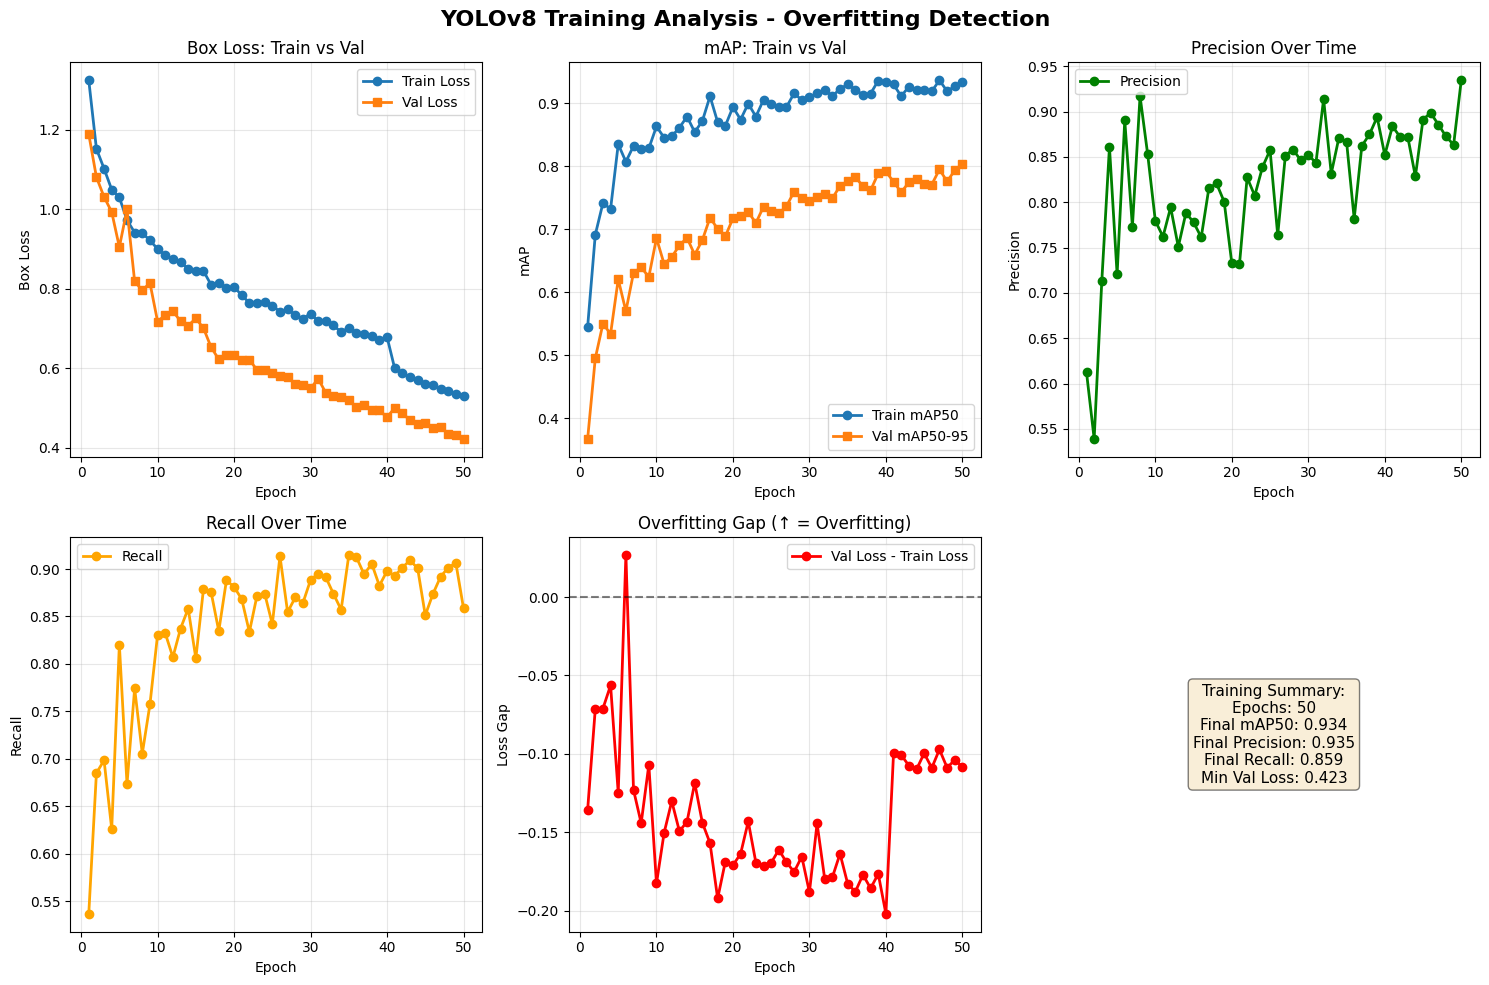


OVERFITTING DIAGNOSIS

📊 Loss Analysis:
   Final Train Loss: 0.5309
   Final Val Loss:   0.4226
   Gap:              -0.1084 (-20.4%)
   ✅ No significant overfitting - Good generalization!

🎯 mAP Analysis:
   Final Train mAP50:    0.9339
   Final Val mAP50-95:   0.8039
   Gap:                  0.1300
   ⚡ Mild overfitting - Consider regularization

📈 Training Trend:
   ℹ️  Validation mAP still improving - Could train longer



In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Load your model
model = YOLO('runs/pose/attention-det-v1/weights/best.pt')

# Path to results
results_path = Path('runs/pose/attention-det-v1/results.csv')

# Read training results
df = pd.read_csv(results_path)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('YOLOv8 Training Analysis - Overfitting Detection', fontsize=16, fontweight='bold')

# 1. Loss Curves
ax = axes[0, 0]
ax.plot(df['epoch'], df['train/box_loss'], label='Train Loss', linewidth=2, marker='o')
ax.plot(df['epoch'], df['val/box_loss'], label='Val Loss', linewidth=2, marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Box Loss')
ax.set_title('Box Loss: Train vs Val')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. mAP50 Curves
ax = axes[0, 1]
ax.plot(df['epoch'], df['metrics/mAP50(B)'], label='Train mAP50', linewidth=2, marker='o')
ax.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='Val mAP50-95', linewidth=2, marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('mAP: Train vs Val')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Precision
ax = axes[0, 2]
ax.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linewidth=2, marker='o', color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('Precision')
ax.set_title('Precision Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Recall
ax = axes[1, 0]
ax.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linewidth=2, marker='o', color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Recall')
ax.set_title('Recall Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Overfitting Gap (Loss difference)
ax = axes[1, 1]
loss_gap = df['val/box_loss'] - df['train/box_loss']
ax.plot(df['epoch'], loss_gap, label='Val Loss - Train Loss', linewidth=2, marker='o', color='red')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss Gap')
ax.set_title('Overfitting Gap (↑ = Overfitting)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.fill_between(df['epoch'], 0, loss_gap, where=(loss_gap > 0), alpha=0.3, color='red', label='Overfitting Area')

# 6. Class Distribution
ax = axes[1, 2]
results_yaml_path = Path('runs/detect/attention-det-v1/results.yaml')
# Just show final metrics summary
ax.text(0.5, 0.5, 'Training Summary:\n' +
        f"Epochs: {len(df)}\n" +
        f"Final mAP50: {df['metrics/mAP50(B)'].iloc[-1]:.3f}\n" +
        f"Final Precision: {df['metrics/precision(B)'].iloc[-1]:.3f}\n" +
        f"Final Recall: {df['metrics/recall(B)'].iloc[-1]:.3f}\n" +
        f"Min Val Loss: {df['val/box_loss'].min():.3f}",
        ha='center', va='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.axis('off')

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("OVERFITTING DIAGNOSIS")
print("="*60)

# Calculate overfitting indicators
final_train_loss = df['train/box_loss'].iloc[-1]
final_val_loss = df['val/box_loss'].iloc[-1]
loss_gap = final_val_loss - final_train_loss
loss_gap_percent = (loss_gap / final_train_loss) * 100

print(f"\n📊 Loss Analysis:")
print(f"   Final Train Loss: {final_train_loss:.4f}")
print(f"   Final Val Loss:   {final_val_loss:.4f}")
print(f"   Gap:              {loss_gap:.4f} ({loss_gap_percent:.1f}%)")

if loss_gap > 0.05:
    print(f"   ⚠️  OVERFITTING DETECTED! Val loss is significantly higher")
elif loss_gap > 0.01:
    print(f"   ⚡ Mild overfitting - Monitor closely")
else:
    print(f"   ✅ No significant overfitting - Good generalization!")

# mAP analysis
final_train_map = df['metrics/mAP50(B)'].iloc[-1]
final_val_map = df['metrics/mAP50-95(B)'].iloc[-1]
map_gap = final_train_map - final_val_map

print(f"\n🎯 mAP Analysis:")
print(f"   Final Train mAP50:    {final_train_map:.4f}")
print(f"   Final Val mAP50-95:   {final_val_map:.4f}")
print(f"   Gap:                  {map_gap:.4f}")

if map_gap > 0.15:
    print(f"   ⚠️  OVERFITTING DETECTED! Large gap between train and val")
elif map_gap > 0.05:
    print(f"   ⚡ Mild overfitting - Consider regularization")
else:
    print(f"   ✅ Good generalization!")

# Check if metrics plateau
val_map_plateau = df['metrics/mAP50-95(B)'].tail(5).std() < 0.01

print(f"\n📈 Training Trend:")
if val_map_plateau:
    print(f"   ℹ️  Validation mAP plateaued - Training completed well")
else:
    print(f"   ℹ️  Validation mAP still improving - Could train longer")

print("\n" + "="*60)